In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import PIL 
import scipy.io
import cv2
import os
import scipy as sp
from skimage.morphology import disk, reconstruction


In [100]:
# All the path 
projet_path = os.getcwd()
image_path = os.path.join(projet_path, "Lame_criblee")
mask_path = os.path.join(projet_path, "Terrain")

In [101]:
im_name = "LC001"
if os.path.exists(os.path.join(image_path, f"{im_name}.jpg")): 
    im = cv2.imread(f'{image_path}/{im_name}.jpg')
elif os.path.exists(os.path.join(image_path, f"{im_name}.png")):
    im = cv2.imread(f'{image_path}/{im_name}.png')
else : 
    print("The file path does not exist")
[H, W, I] = im.shape
#plt.imshow(im)
im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

In [102]:
# Charger le .mat
mat = scipy.io.loadmat(f'Terrain/{im_name}_VT.mat')
# Récupérer juste la matrice et la mettre dnas la varibale mask (car binaire)
mask = mat['seeds']
#plt.imshow(mask, cmap=plt.cm.gray)

In [103]:
# Overlap image and mask
colormap = colors.ListedColormap(['white', 'red'])
#plt.imshow(im, cmap=plt.cm.gray)
#plt.imshow(mask, cmap = colormap, alpha = 0.2)

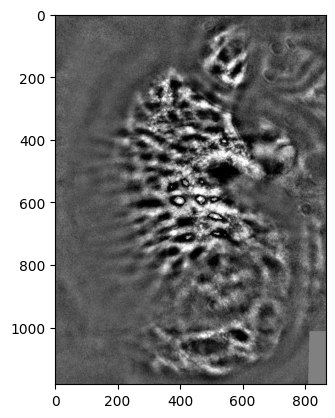

In [104]:
# Cleaning the dark rectangles
_, binary = cv2.threshold(im, 10, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
created_mask = np.ones(im.shape, dtype=np.uint8) * 255

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if (w > 20 and h > 20) and (x < 10 or x + w > im.shape[1] - 10):
        cv2.drawContours(created_mask, [contour], -1, 0, -1)

im[created_mask == 0] = 128
plt.imshow(im, cmap = plt.cm.gray)

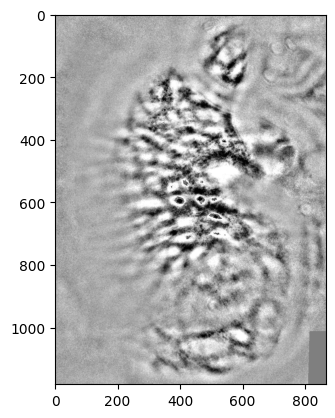

In [105]:
# inverser couleurs images
im_inverted = 255 - im
plt.imshow(im_inverted, cmap = plt.cm.gray)

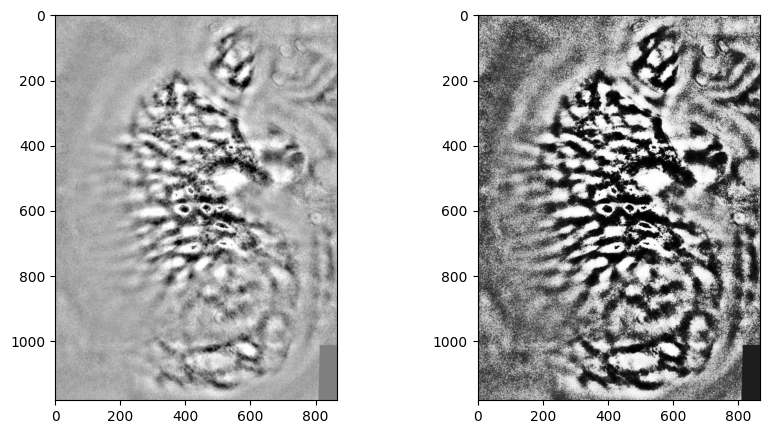

In [106]:
# Egalisation de l'histogramme de niveaux de gris
egal_image = cv2.equalizeHist(im_inverted)    
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(im_inverted, cmap = plt.cm.gray)
axes[1].imshow(egal_image, cmap = plt.cm.gray)

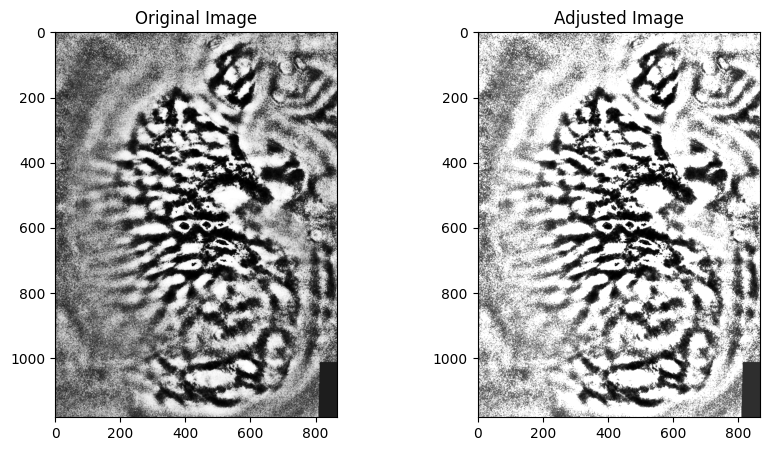

In [107]:
contrast_coeff = 1.6
brightness_coeff = 0 #coeff entre 1 et 3 (en dessous de 1, diminue le contrast)
brighter_image = egal_image*contrast_coeff+brightness_coeff
brighter_image = np.clip(brighter_image, 0, 255)  # Limit values to the range [0, 255]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(egal_image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(brighter_image, cmap='gray')
axes[1].set_title('Adjusted Image')
plt.show()

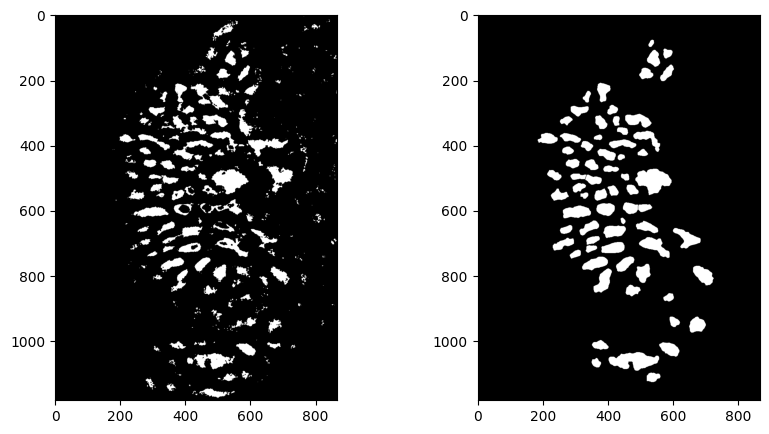

In [108]:
# Put a threshold on the image 
blur_im = cv2.GaussianBlur(egal_image,(5,5),0)
ret, seuil_im = cv2.threshold(blur_im, 230, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(seuil_im-255, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [111]:
# Fill the missing spots inside the white structures and delete noise
SE3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
SE5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
SE7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
SE9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))

# Filtres alternées séquentiels
N = 5
tailles = range(0, N)
SE = [disk(r) for r in tailles]

fas = egal_image.copy()
for i in range(N):
    r = tailles[i]
    selem = SE[i]

    # Open by reconstruction
    opened = cv2.morphologyEx(fas, cv2.MORPH_OPEN, selem)
    open_reconstructed = reconstruction(opened, fas, method='dilation').astype(np.uint8)
    
    # Close by reconstruction
    closed = cv2.morphologyEx(open_reconstructed, cv2.MORPH_CLOSE, selem)
    fas = 1 - reconstruction(1 - closed, 1 - open_reconstructed, method='erosion').astype(np.uint8)

# To visualize the final result
plt.imshow(fas, cmap = plt.cm.gray)

closing1 = cv2.morphologyEx(egal_image, cv2.MORPH_CLOSE, SE3)
opening1 = cv2.morphologyEx(closing1, cv2.MORPH_OPEN, SE5)
closing2 = cv2.morphologyEx(egal_image, cv2.MORPH_CLOSE, SE3)
opening2 = cv2.morphologyEx(closing2, cv2.MORPH_OPEN, SE7)
opening3 = cv2.morphologyEx(egal_image, cv2.MORPH_OPEN, SE5)
closing3 = cv2.morphologyEx(opening3, cv2.MORPH_CLOSE, SE9)
opening4 = cv2.morphologyEx(egal_image, cv2.MORPH_OPEN, SE5)
closing4 = cv2.morphologyEx(opening4, cv2.MORPH_CLOSE, SE7)
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(opening1, cmap = plt.cm.gray)
axes[1].imshow(opening2, cmap = plt.cm.gray)
axes[2].imshow(closing3, cmap = plt.cm.gray)
axes[3].imshow(closing4, cmap = plt.cm.gray)
#axes[0].imshow(mask, cmap = plt.cm.gray)
#axes[0].imshow(opening1, cmap = colormap, alpha = 0.5)
#axes[1].imshow(mask, cmap = plt.cm.gray)
#axes[1].imshow(opening2, cmap = colormap, alpha = 0.5)
#axes[2].imshow(mask, cmap = plt.cm.gray)
#axes[2].imshow(opening3, cmap = colormap, alpha = 0.5)
#axes[3].imshow(mask, cmap = plt.cm.gray)
#axes[3].imshow(opening4, cmap = colormap, alpha = 0.5)
plt.savefig(f'Results/openclose_{im_name}')

ValueError: Intensity of seed image must be greater than that of the mask image for reconstruction by erosion.

In [ ]:
# Put a threshold on the image 
blur_im = cv2.GaussianBlur(opening2,(5,5),0)
ret, seuil_im = cv2.threshold(blur_im, 230, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(seuil_im-255, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
# Not working at all
tophat1 = cv2.morphologyEx(egal_image, cv2.MORPH_TOPHAT, SE7)
tophat2 = cv2.morphologyEx(egal_image, cv2.MORPH_TOPHAT, SE9)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask, cmap = plt.cm.gray)
axes[0].imshow(tophat1, cmap = colormap, alpha = 0.5)
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].imshow(tophat2, cmap = colormap, alpha = 0.5)

In [ ]:
# Calcul du gradient 
grad_x = cv2.Sobel(egal_image, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(egal_image, cv2.CV_64F, 0, 1, ksize=3)

gradient_magnitude = cv2.magnitude(grad_x, grad_y)
gradient_magnitude = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX)
plt.imshow(gradient_magnitude, cmap='gray')

In [ ]:
# canny edge detection 
canny_image = cv2.Canny(egal_image, 50,100)
plt.imshow(canny_image, cmap = plt.cm.gray)

In [ ]:
# Put a threshold on the image with Otsu
ret2,th2 = cv2.threshold(egal_image,10,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(th2, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
# Put a threshold on the image with an adaptative gaussian threhsold 
gauss_seuil_im = cv2.adaptiveThreshold(egal_image,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,15,2)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gauss_seuil_im, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
# Put a threshold on the image with Otsu and a previous blur
blur = cv2.GaussianBlur(egal_image,(5,5),0)
ret3,th3 = cv2.threshold(blur,20,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(th3, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
def imfilter(im,noyau):
    # Creation du bordage en miroir 
    h,w = np.shape(noyau)
    hbis = int(np.floor(h/2))
    wbis = int(np.floor(w/2))
    im_bis = np.pad(im, ((hbis,hbis),(wbis,wbis)),'symmetric')
    [Hbis,Wbis] = im_bis.shape
    # Delete le bordage 
    conv = sp.signal.convolve2d(im_bis, noyau)
    conv_bis = conv[hbis:Hbis-hbis, wbis:Wbis-wbis]
    return conv_bis

In [ ]:
# Filtre dérivatuer, passe haut, dessine les contours 
def passeHaut(im): 
    noyauhoriz = np.array([[-1, 0, 1]])
    noyauvert = np.array([[-1], [0], [1]])

    imhoriz = imfilter(im,noyauhoriz)
    imvert = imfilter(im,noyauvert)
    imcontour = np.sqrt(imhoriz**2 + imvert**2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(im, cmap=plt.cm.gray)
    axes[1].imshow(imcontour, cmap=plt.cm.gray)

    return 
passeHaut(egal_image)

In [ ]:
# Noyau Lapalcien ou noyau dérivateur, fait apparaitre les coutours 
def laplacien(im, nb_voisins):
    if nb_voisins == 4 : 
        m_laplacien = [[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]]
    elif nb_voisins == 8 : 
        m_laplacien = [[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]]
    else : 
        return 0
    filtered_im = im*m_laplacien
    return filtered_im